# Pretrained SER Evaluation — UA-SER

This notebook **runs inference** with three off-the-shelf speech emotion recognition models on the speaker-disjoint UA-SER test set (181 clips, 4 emotions: angry / happy / neutral / sad), then produces a full comparative analysis.

| Model | Source | Training data |
|-------|--------|---------------|
| SpeechBrain wav2vec2-IEMOCAP | `speechbrain/emotion-recognition-wav2vec2-IEMOCAP` | IEMOCAP (English) |
| SUPERB wav2vec2-large-ER | `superb/wav2vec2-large-superb-er` | IEMOCAP + MSP-IMPROV (English) |
| emotion2vec+ base | `iic/emotion2vec_plus_base` | large-scale multilingual mix |

All models are evaluated **zero-shot** — no Ukrainian data was used in their training.

In [ ]:
import torch

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {torch.cuda.get_device_name(0)} ({props.total_memory / 1e9:.1f} GB)")
else:
    print("WARNING: No GPU. Go to Runtime > Change runtime type > T4 GPU")

!pip install -q speechbrain funasr transformers librosa tqdm

---
## 1. Mount Drive & Unpack Data

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import zipfile
from pathlib import Path

DRIVE_PROJECT = Path("/content/drive/MyDrive/thesis_new")
DATA_ZIP = DRIVE_PROJECT / "data.zip"
LOCAL_DATA = Path("/content/ser_data")

if not LOCAL_DATA.exists():
    assert DATA_ZIP.exists(), (
        f"Upload data.zip to Google Drive at: {DATA_ZIP}\n"
        "The zip should contain: clips/, dataset.csv"
    )
    with zipfile.ZipFile(DATA_ZIP, "r") as zf:
        zf.extractall(LOCAL_DATA)

DATA_ROOT = LOCAL_DATA if (LOCAL_DATA / "dataset.csv").exists() else     next(d for d in LOCAL_DATA.iterdir() if d.is_dir())

AUDIO_DIR = DATA_ROOT / "clips"
print(f"Data root:  {DATA_ROOT}")
print(f"Audio dir:  {AUDIO_DIR}  ({len(list(AUDIO_DIR.glob('*.wav')))} WAV files)")

---
## 2. Run Pretrained Models

In [ ]:
import warnings
import numpy as np
import pandas as pd
import librosa
from tqdm.auto import tqdm
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, f1_score,
    cohen_kappa_score, classification_report,
)

warnings.filterwarnings("ignore")

EMOTIONS = ["angry", "happy", "neutral", "sad"]
LABEL_MAP = {"ang": "angry", "hap": "happy", "neu": "neutral", "sad": "sad"}
SAMPLE_RATE = 16_000

df = pd.read_csv(DATA_ROOT / "dataset.csv")
test_df = df[df["split"] == "test"].reset_index(drop=True)
y_true = test_df["emotion"].tolist()

print(f"Test set: {len(test_df)} clips")
print(f"Distribution: {test_df['emotion'].value_counts().sort_index().to_dict()}")

In [ ]:
from speechbrain.inference.interfaces import foreign_class

print("Loading SpeechBrain emotion-recognition-wav2vec2-IEMOCAP ...")
sb_clf = foreign_class(
    source="speechbrain/emotion-recognition-wav2vec2-IEMOCAP",
    pymodule_file="custom_interface.py",
    classname="CustomEncoderWav2vec2Classifier",
)

sb_preds = []
for fname in tqdm(test_df["filename"], desc="SpeechBrain"):
    _, _, _, text_lab = sb_clf.classify_file(str(AUDIO_DIR / fname))
    sb_preds.append(LABEL_MAP.get(text_lab[0], text_lab[0]))
print("Done.")

In [ ]:
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2FeatureExtractor

print("Loading SUPERB wav2vec2-large-superb-er ...")
superb_model = Wav2Vec2ForSequenceClassification.from_pretrained("superb/wav2vec2-large-superb-er")
superb_feat = Wav2Vec2FeatureExtractor.from_pretrained("superb/wav2vec2-large-superb-er")
superb_model.eval()

superb_preds = []
for fname in tqdm(test_df["filename"], desc="SUPERB"):
    y, _ = librosa.load(str(AUDIO_DIR / fname), sr=SAMPLE_RATE, mono=True)
    inputs = superb_feat(y, sampling_rate=SAMPLE_RATE, return_tensors="pt", padding=True)
    with torch.no_grad():
        logits = superb_model(**inputs).logits
    raw = superb_model.config.id2label[logits.argmax(-1).item()]
    superb_preds.append(LABEL_MAP.get(raw, raw))
print("Done.")

In [ ]:
from funasr import AutoModel as FunASRModel

EMOTION2VEC_LABELS = [
    "angry", "disgusted", "fearful", "happy",
    "neutral", "other", "sad", "surprised", "unknown",
]
TARGET_IDX = [EMOTION2VEC_LABELS.index(e) for e in EMOTIONS]

print("Loading emotion2vec+ base ...")
e2v_model = FunASRModel(model="iic/emotion2vec_plus_base")

e2v_preds = []
for fname in tqdm(test_df["filename"], desc="emotion2vec+"):
    res = e2v_model.generate(
        str(AUDIO_DIR / fname),
        granularity="utterance",
        extract_embedding=False,
    )
    scores = res[0]["scores"]
    target_scores = {EMOTIONS[i]: scores[idx] for i, idx in enumerate(TARGET_IDX)}
    e2v_preds.append(max(target_scores, key=target_scores.get))
print("Done.")

In [ ]:
MODEL_PREDS = {
    "SpeechBrain wav2vec2-IEMOCAP": sb_preds,
    "SUPERB wav2vec2-large-ER":     superb_preds,
    "emotion2vec+ base":            e2v_preds,
}

majority_class = max(set(y_true), key=y_true.count)
maj_preds = [majority_class] * len(y_true)

all_results = [
    {
        "Model": "Chance (random)", "UAR": 0.25, "Accuracy": 0.25,
        "Macro F1": 0.0, "Weighted F1": 0.0, "Kappa": 0.0,
        **{f"{e.capitalize()} R": 0.25 for e in EMOTIONS},
    },
    {
        "Model": f"Majority ({majority_class})",
        "UAR": balanced_accuracy_score(y_true, maj_preds),
        "Accuracy": accuracy_score(y_true, maj_preds),
        "Macro F1": 0.0, "Weighted F1": 0.0, "Kappa": 0.0,
        **{f"{e.capitalize()} R": (1.0 if e == majority_class else 0.0) for e in EMOTIONS},
    },
]

all_per_class = []
pred_df_out = test_df[["filename", "emotion"]].copy()

for model_name, preds in MODEL_PREDS.items():
    report = classification_report(
        y_true, preds, target_names=EMOTIONS, labels=EMOTIONS,
        output_dict=True, zero_division=0,
    )
    row = {
        "Model": model_name,
        "UAR": balanced_accuracy_score(y_true, preds),
        "Accuracy": accuracy_score(y_true, preds),
        "Macro F1": f1_score(y_true, preds, average="macro", labels=EMOTIONS),
        "Weighted F1": f1_score(y_true, preds, average="weighted", labels=EMOTIONS),
        "Kappa": cohen_kappa_score(y_true, preds),
        **{f"{e.capitalize()} R": report[e]["recall"] for e in EMOTIONS},
    }
    all_results.append(row)
    for e in EMOTIONS:
        all_per_class.append({
            "Model": model_name, "Emotion": e,
            "precision": report[e]["precision"],
            "recall":    report[e]["recall"],
            "f1":        report[e]["f1-score"],
            "support":   report[e]["support"],
        })
    safe = model_name.lower().replace(" ", "_").replace("+", "plus")
    pred_df_out[f"pred_{safe}"] = preds
    print(f"\n{model_name}  UAR={row['UAR']:.3f}  Acc={row['Accuracy']:.3f}  F1={row['Macro F1']:.3f}")
    print(classification_report(y_true, preds, target_names=EMOTIONS, labels=EMOTIONS, digits=3))

col_order = ["Model", "UAR", "Accuracy", "Macro F1", "Weighted F1", "Kappa"] +             [f"{e.capitalize()} R" for e in EMOTIONS]
results_df  = pd.DataFrame(all_results)[col_order]
per_class_df = pd.DataFrame(all_per_class)
pred_df_out.to_csv(DATA_ROOT / "pretrained_ser_predictions.csv", index=False)
results_df.to_csv(DATA_ROOT  / "pretrained_ser_results.csv",     index=False)
per_class_df.to_csv(DATA_ROOT / "pretrained_ser_per_class.csv",  index=False)
print("\nCSVs saved to", DATA_ROOT)

---
## 3. Results & Analysis

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'serif', 'axes.titlesize': 14, 'axes.labelsize': 12,
})

EMOTIONS = ['angry', 'happy', 'neutral', 'sad']
EMOTION_COLORS = {'angry': '#e74c3c', 'happy': '#f39c12', 'neutral': '#3498db', 'sad': '#2c3e50'}
MODEL_COLORS = {'SpeechBrain wav2vec2-IEMOCAP': '#3498db', 'SUPERB wav2vec2-large-ER': '#e67e22', 'emotion2vec+ base': '#2ecc71'}
MODEL_SHORT = {'SpeechBrain wav2vec2-IEMOCAP': 'SpeechBrain', 'SUPERB wav2vec2-large-ER': 'SUPERB', 'emotion2vec+ base': 'emotion2vec+'}

BASE = DATA_ROOT
results_df  = pd.read_csv(BASE / 'pretrained_ser_results.csv')
per_class_df = pd.read_csv(BASE / 'pretrained_ser_per_class.csv')
pred_df     = pd.read_csv(BASE / 'pretrained_ser_predictions.csv')
dataset_df  = pd.read_csv(BASE / 'dataset.csv')

models = results_df[~results_df['Model'].str.contains('Chance|Majority')]['Model'].tolist()
print(f'Loaded results for {len(models)} models on {len(pred_df)} test samples')
print(f'Models: {models}')

Loaded results for 3 models on 190 test samples
Models: ['SpeechBrain wav2vec2-IEMOCAP', 'SUPERB wav2vec2-large-ER', 'emotion2vec+ base']


---
## 1. Aggregate Performance Table

In [2]:
display_df = results_df.copy()
pct_cols = ['UAR', 'Accuracy', 'Macro F1', 'Weighted F1', 'Angry R', 'Happy R', 'Neutral R', 'Sad R']
for c in pct_cols:
    display_df[c] = display_df[c].apply(lambda x: f'{x:.1%}')
display_df['Kappa'] = display_df['Kappa'].apply(lambda x: f'{x:.3f}')

display(Markdown('### Overall Metrics (incl. baselines)'))
display(display_df.style.set_properties(**{'text-align': 'center'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}]
))

### Overall Metrics (incl. baselines)

,Model,UAR,Accuracy,Macro F1,Weighted F1,Kappa,Angry R,Happy R,Neutral R,Sad R
0,Chance (random),25.0%,25.0%,0.0%,0.0%,0.000,25.0%,25.0%,25.0%,25.0%
1,Majority (angry),25.0%,27.4%,0.0%,0.0%,0.000,100.0%,0.0%,0.0%,0.0%
2,SpeechBrain wav2vec2-IEMOCAP,41.3%,41.6%,37.2%,37.8%,0.222,42.3%,57.1%,61.4%,4.4%
3,SUPERB wav2vec2-large-ER,35.3%,35.8%,29.1%,29.7%,0.141,23.1%,81.6%,36.4%,0.0%
4,emotion2vec+ base,53.9%,53.2%,52.1%,52.3%,0.381,34.6%,61.2%,86.4%,33.3%


In [3]:
model_rows = results_df[~results_df['Model'].str.contains('Chance|Majority')].copy()

display(Markdown('### Model-only comparison'))
summary = model_rows[['Model', 'UAR', 'Accuracy', 'Macro F1', 'Weighted F1', 'Kappa']].copy()
for c in ['UAR', 'Accuracy', 'Macro F1', 'Weighted F1']:
    summary[c] = summary[c].apply(lambda x: f'{x:.1%}')
summary['Kappa'] = summary['Kappa'].apply(lambda x: f'{x:.3f}')

def highlight_best(s):
    if s.name in ['UAR', 'Accuracy', 'Macro F1', 'Weighted F1', 'Kappa']:
        vals = [float(v.strip('%')) for v in s]
        best_idx = vals.index(max(vals))
        return ['font-weight: bold; color: #27ae60' if i == best_idx else '' for i in range(len(s))]
    return ['' for _ in s]

display(summary.style.apply(highlight_best).set_properties(**{'text-align': 'center'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]}]
))

### Model-only comparison

,Model,UAR,Accuracy,Macro F1,Weighted F1,Kappa
2,SpeechBrain wav2vec2-IEMOCAP,41.3%,41.6%,37.2%,37.8%,0.222
3,SUPERB wav2vec2-large-ER,35.3%,35.8%,29.1%,29.7%,0.141
4,emotion2vec+ base,53.9%,53.2%,52.1%,52.3%,0.381


---
## 2. Aggregate Metrics Bar Chart

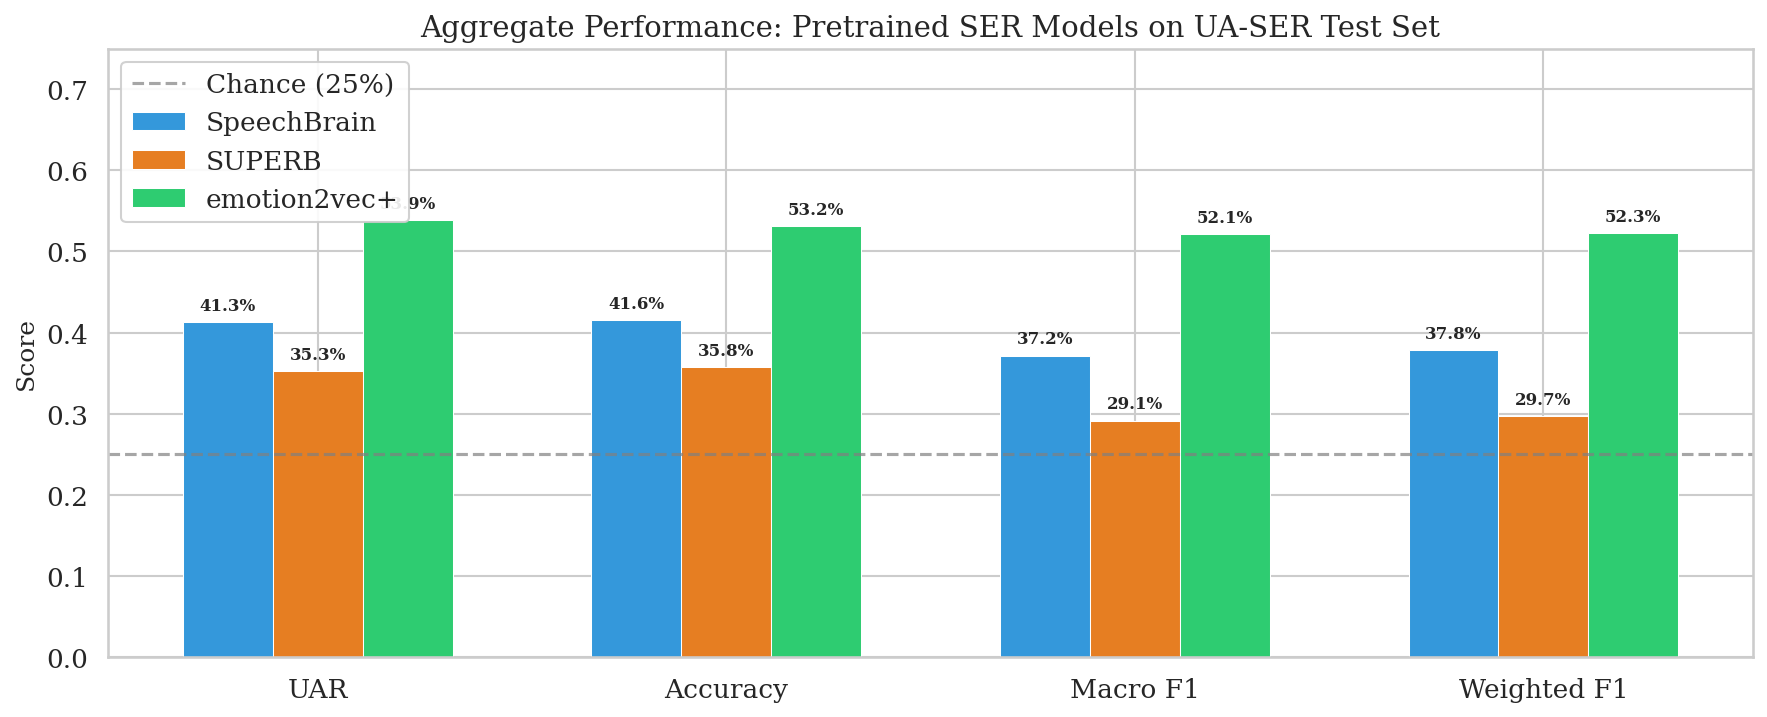

In [4]:
model_rows = results_df[~results_df['Model'].str.contains('Chance|Majority')].copy()
metrics = ['UAR', 'Accuracy', 'Macro F1', 'Weighted F1']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics))
width = 0.22

for i, (_, row) in enumerate(model_rows.iterrows()):
    model_name = row['Model']
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=MODEL_SHORT[model_name],
                  color=MODEL_COLORS[model_name], edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.1%}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.7, label='Chance (25%)')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 0.75)
ax.set_ylabel('Score')
ax.set_title('Aggregate Performance: Pretrained SER Models on UA-SER Test Set')
ax.legend(loc='upper left', framealpha=0.9)
fig.tight_layout()
plt.show()

---
## 3. Per-Class Recall Comparison

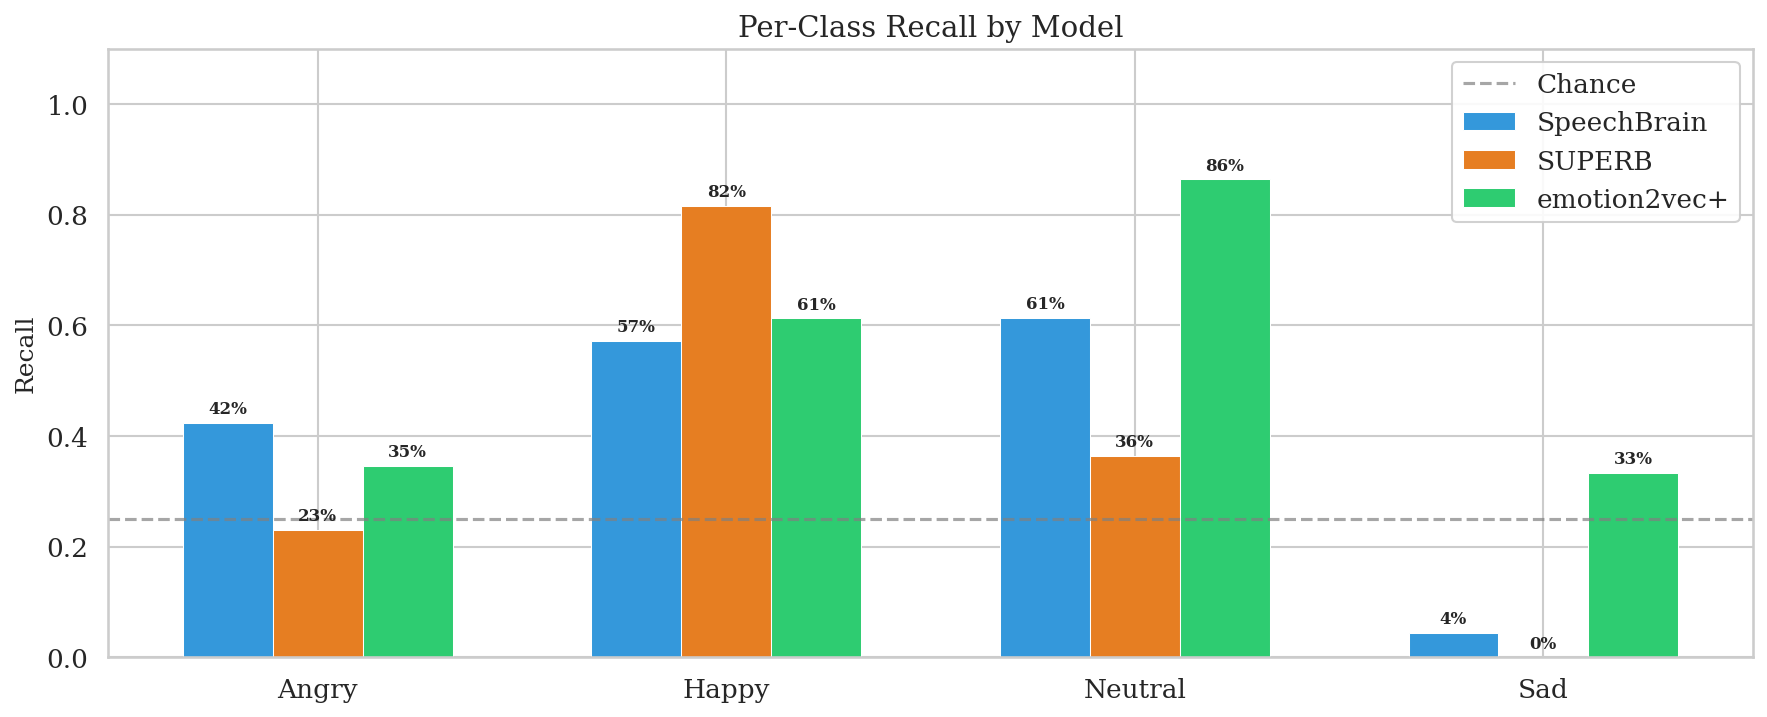

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(EMOTIONS))
width = 0.22

for i, model_name in enumerate(models):
    recall_cols = [f'{e.capitalize()} R' for e in EMOTIONS]
    row = results_df[results_df['Model'] == model_name].iloc[0]
    vals = [row[c] for c in recall_cols]
    bars = ax.bar(x + i * width, vals, width, label=MODEL_SHORT[model_name],
                  color=MODEL_COLORS[model_name], edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.0%}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.7, label='Chance')
ax.set_xticks(x + width)
ax.set_xticklabels([e.capitalize() for e in EMOTIONS])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Recall')
ax.set_title('Per-Class Recall by Model')
ax.legend(loc='upper right', framealpha=0.9)
fig.tight_layout()
plt.show()

---
## 4. Per-Class Precision / Recall / F1 Heatmap

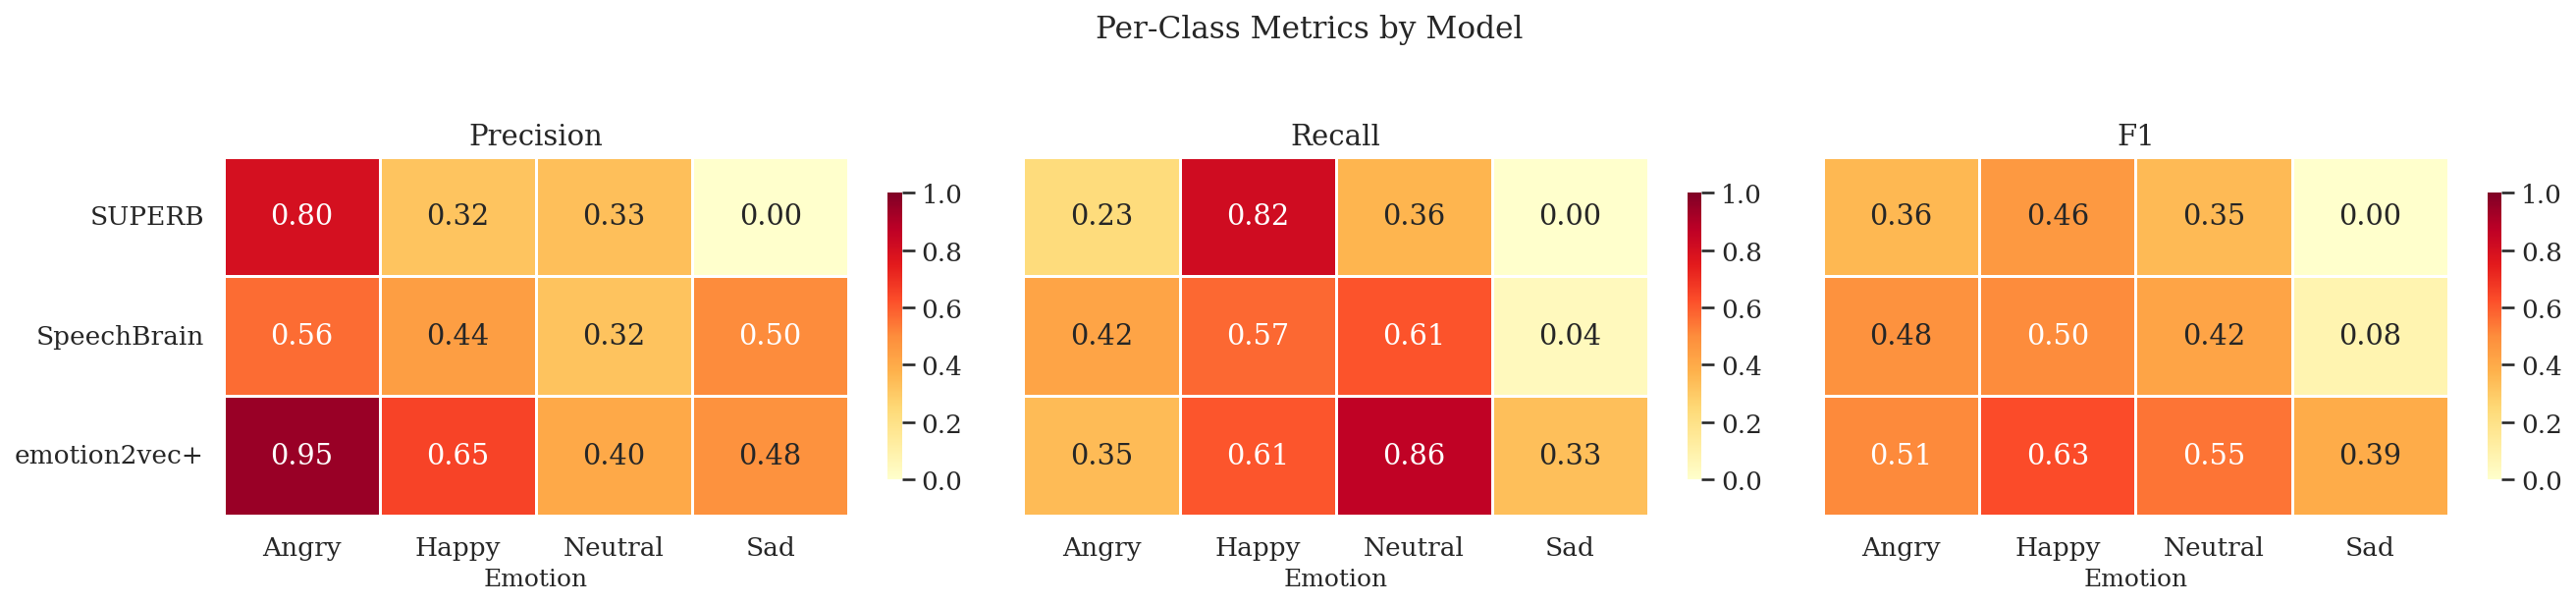

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, metric_name in zip(axes, ['precision', 'recall', 'f1']):
    pivot = per_class_df.pivot(index='Model', columns='Emotion', values=metric_name)
    pivot = pivot[EMOTIONS]
    pivot.index = [MODEL_SHORT.get(m, m) for m in pivot.index]

    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                vmin=0, vmax=1, linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(metric_name.capitalize())
    ax.set_ylabel('')
    ax.set_xticklabels([e.capitalize() for e in EMOTIONS], rotation=0)

fig.suptitle('Per-Class Metrics by Model', fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

---
## 5. Confusion Matrices

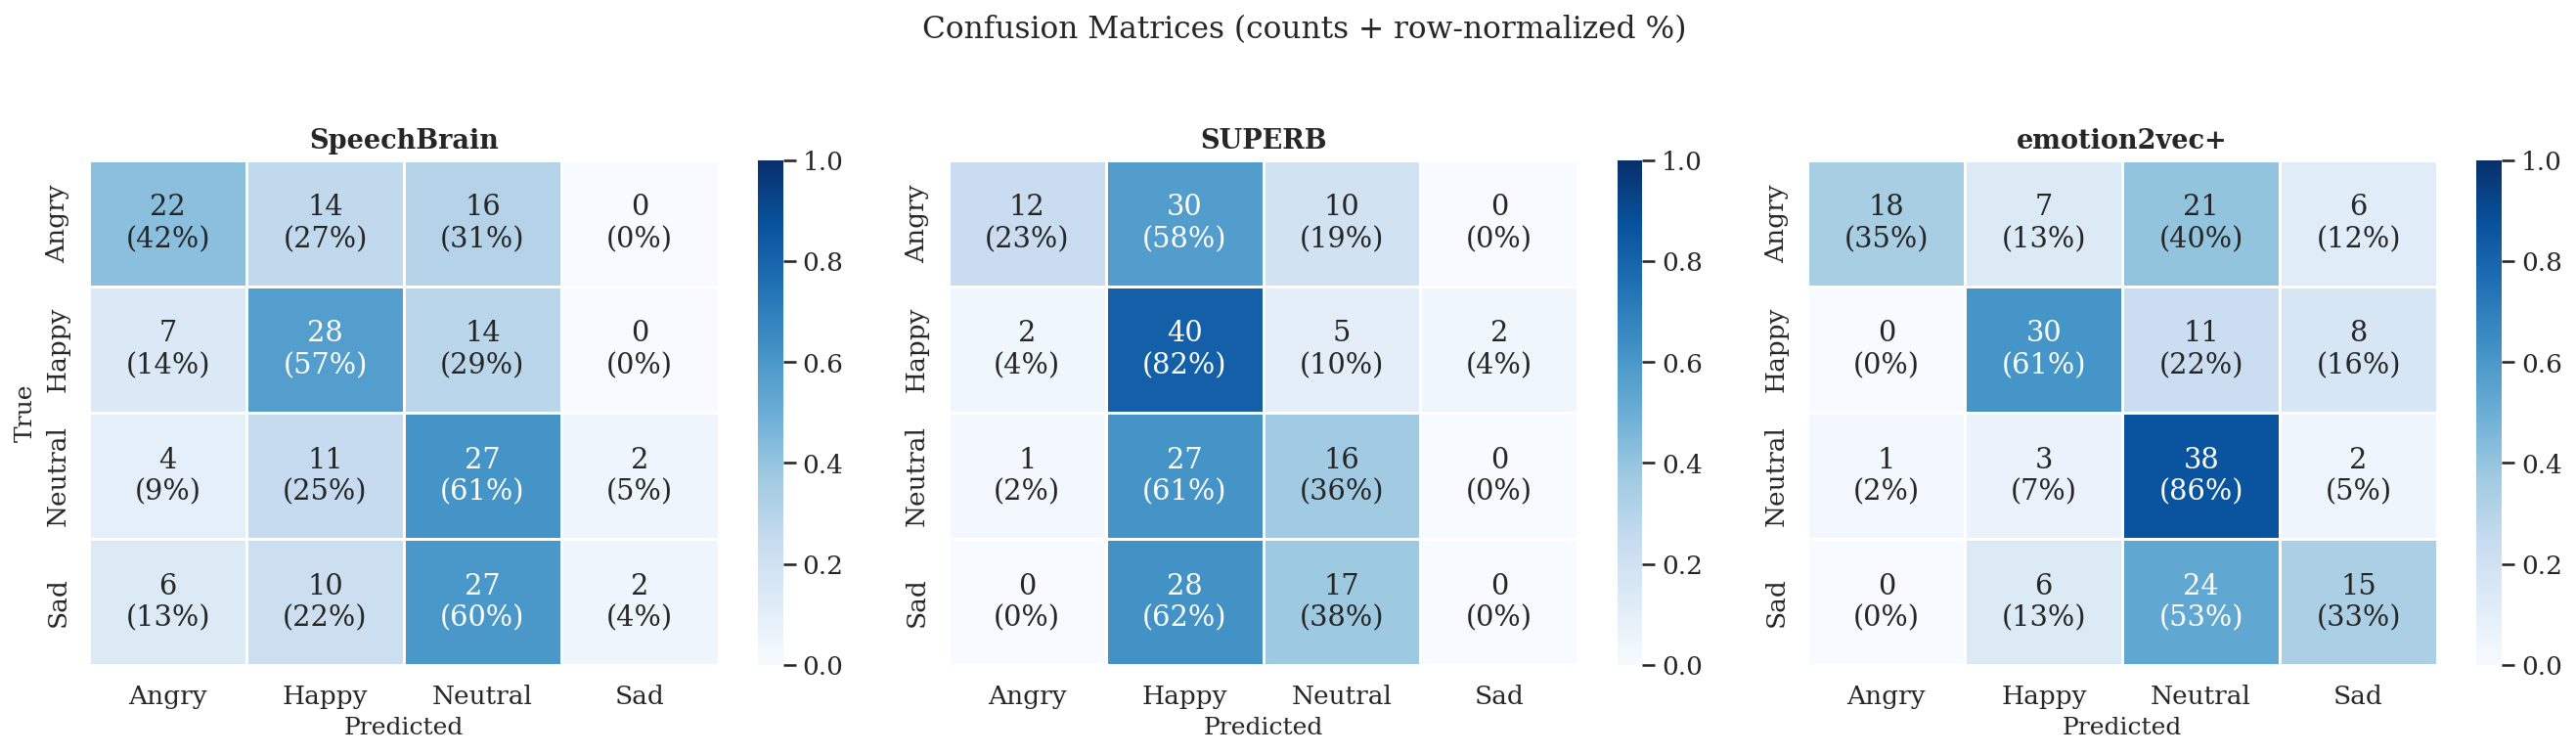

In [7]:
pred_cols = [c for c in pred_df.columns if c.startswith('pred_')]
y_true = pred_df['emotion'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pred_col, model_name in zip(axes, pred_cols, models):
    y_pred = pred_df[pred_col].values
    cm = confusion_matrix(y_true, y_pred, labels=EMOTIONS)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    labels = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(len(EMOTIONS))]
                       for i in range(len(EMOTIONS))])

    sns.heatmap(cm_norm, annot=labels, fmt='', cmap='Blues', ax=ax,
                xticklabels=[e.capitalize() for e in EMOTIONS],
                yticklabels=[e.capitalize() for e in EMOTIONS],
                vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(MODEL_SHORT[model_name], fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True' if ax == axes[0] else '')

fig.suptitle('Confusion Matrices (counts + row-normalized %)', fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

---
## 6. Radar Chart: Per-Class Recall

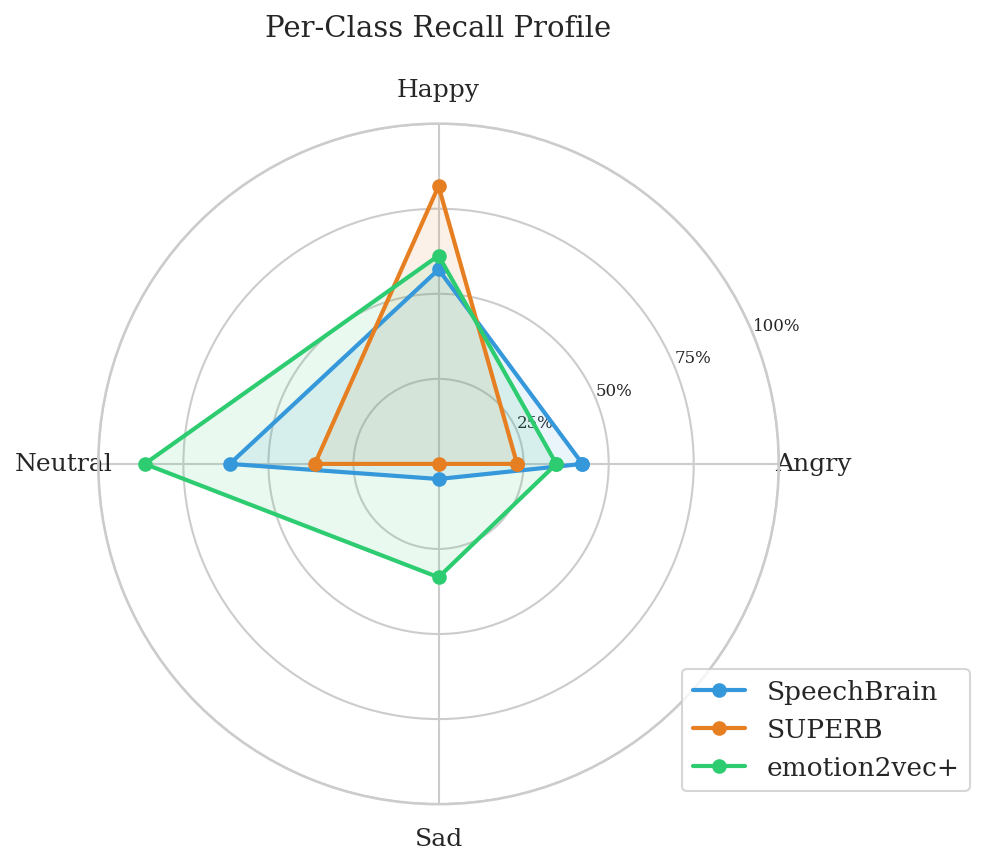

In [8]:
categories = [e.capitalize() for e in EMOTIONS]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for model_name in models:
    row = results_df[results_df['Model'] == model_name].iloc[0]
    vals = [row[f'{e.capitalize()} R'] for e in EMOTIONS]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=MODEL_SHORT[model_name],
            color=MODEL_COLORS[model_name])
    ax.fill(angles, vals, alpha=0.1, color=MODEL_COLORS[model_name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_title('Per-Class Recall Profile', fontsize=14, pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0))
fig.tight_layout()
plt.show()

---
## 7. Model Agreement Analysis

In [9]:
pred_cols = [c for c in pred_df.columns if c.startswith('pred_')]

pred_df['n_models_correct'] = sum(
    (pred_df[c] == pred_df['emotion']).astype(int) for c in pred_cols
)
pred_df['all_agree'] = pred_df[pred_cols].nunique(axis=1) == 1
pred_df['majority_vote'] = pred_df[pred_cols].mode(axis=1)[0]
pred_df['majority_correct'] = pred_df['majority_vote'] == pred_df['emotion']

display(Markdown('### How many models got each sample correct?'))
counts = pred_df['n_models_correct'].value_counts().sort_index()
for n, cnt in counts.items():
    pct = cnt / len(pred_df) * 100
    print(f'  {n}/3 models correct: {cnt:>4} samples ({pct:.1f}%)')

print(f'\nAll 3 models agree on prediction: {pred_df["all_agree"].sum()} / {len(pred_df)} '
      f'({pred_df["all_agree"].mean():.1%})')
print(f'Majority vote accuracy: {pred_df["majority_correct"].mean():.1%}')

### How many models got each sample correct?

  0/3 models correct:   58 samples (30.5%)
  1/3 models correct:   52 samples (27.4%)
  2/3 models correct:   44 samples (23.2%)
  3/3 models correct:   36 samples (18.9%)

All 3 models agree on prediction: 52 / 190 (27.4%)
Majority vote accuracy: 46.8%


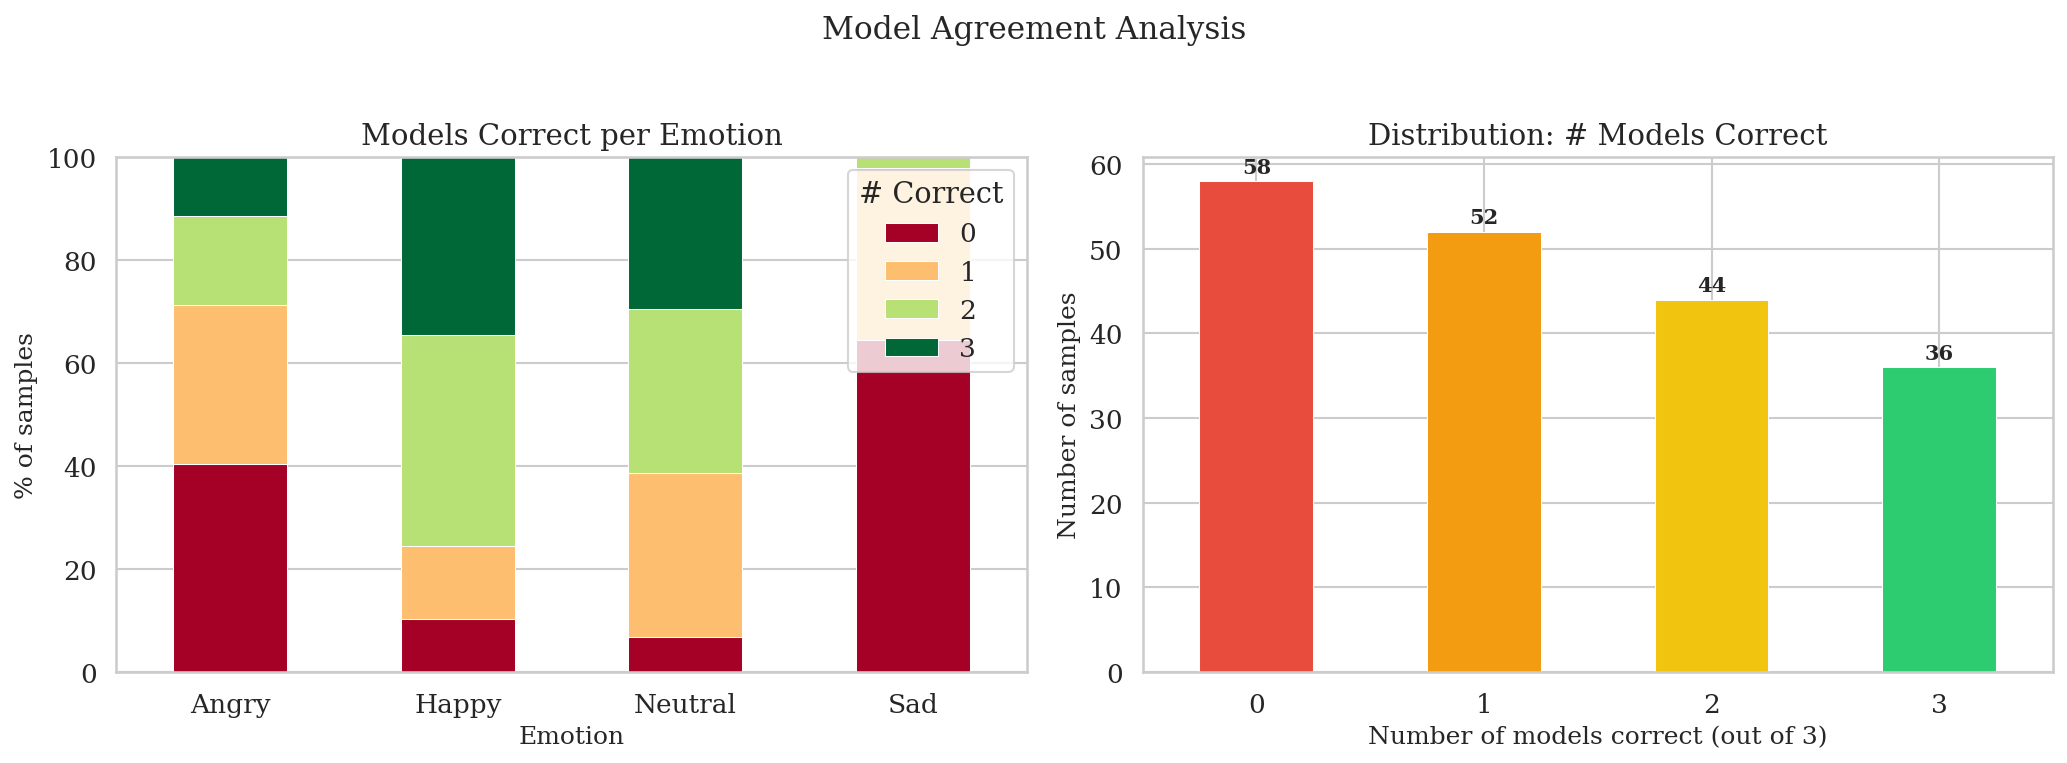

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stacked bar of n_models_correct by emotion
ct = pd.crosstab(pred_df['emotion'], pred_df['n_models_correct'], normalize='index') * 100
ct = ct.reindex(EMOTIONS)
ct.plot.bar(stacked=True, ax=axes[0], colormap='RdYlGn', edgecolor='white', linewidth=0.5)
axes[0].set_title('Models Correct per Emotion')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('% of samples')
axes[0].set_xticklabels([e.capitalize() for e in EMOTIONS], rotation=0)
axes[0].legend(title='# Correct', loc='upper right')

# Right: distribution of n_models_correct
colors_bar = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71']
counts.plot.bar(ax=axes[1], color=colors_bar[:len(counts)], edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribution: # Models Correct')
axes[1].set_xlabel('Number of models correct (out of 3)')
axes[1].set_ylabel('Number of samples')
axes[1].set_xticklabels(counts.index, rotation=0)
for i, (idx, v) in enumerate(counts.items()):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=10)

fig.suptitle('Model Agreement Analysis', fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

---
## 8. Error Pattern Analysis

In [11]:
display(Markdown('### Most common misclassifications per model'))

for model_name, pred_col in zip(models, pred_cols):
    errors = pred_df[pred_df[pred_col] != pred_df['emotion']].copy()
    errors['pair'] = errors['emotion'] + ' → ' + errors[pred_col]
    top_errors = errors['pair'].value_counts().head(5)

    print(f'\n{MODEL_SHORT[model_name]} ({len(errors)} errors / {len(pred_df)} total):')
    for pair, cnt in top_errors.items():
        print(f'  {pair}: {cnt} ({cnt/len(pred_df)*100:.1f}%)')

### Most common misclassifications per model


SpeechBrain (111 errors / 190 total):
  sad → neutral: 27 (14.2%)
  angry → neutral: 16 (8.4%)
  angry → happy: 14 (7.4%)
  happy → neutral: 14 (7.4%)
  neutral → happy: 11 (5.8%)

SUPERB (122 errors / 190 total):
  angry → happy: 30 (15.8%)
  sad → happy: 28 (14.7%)
  neutral → happy: 27 (14.2%)
  sad → neutral: 17 (8.9%)
  angry → neutral: 10 (5.3%)

emotion2vec+ (89 errors / 190 total):
  sad → neutral: 24 (12.6%)
  angry → neutral: 21 (11.1%)
  happy → neutral: 11 (5.8%)
  happy → sad: 8 (4.2%)
  angry → happy: 7 (3.7%)


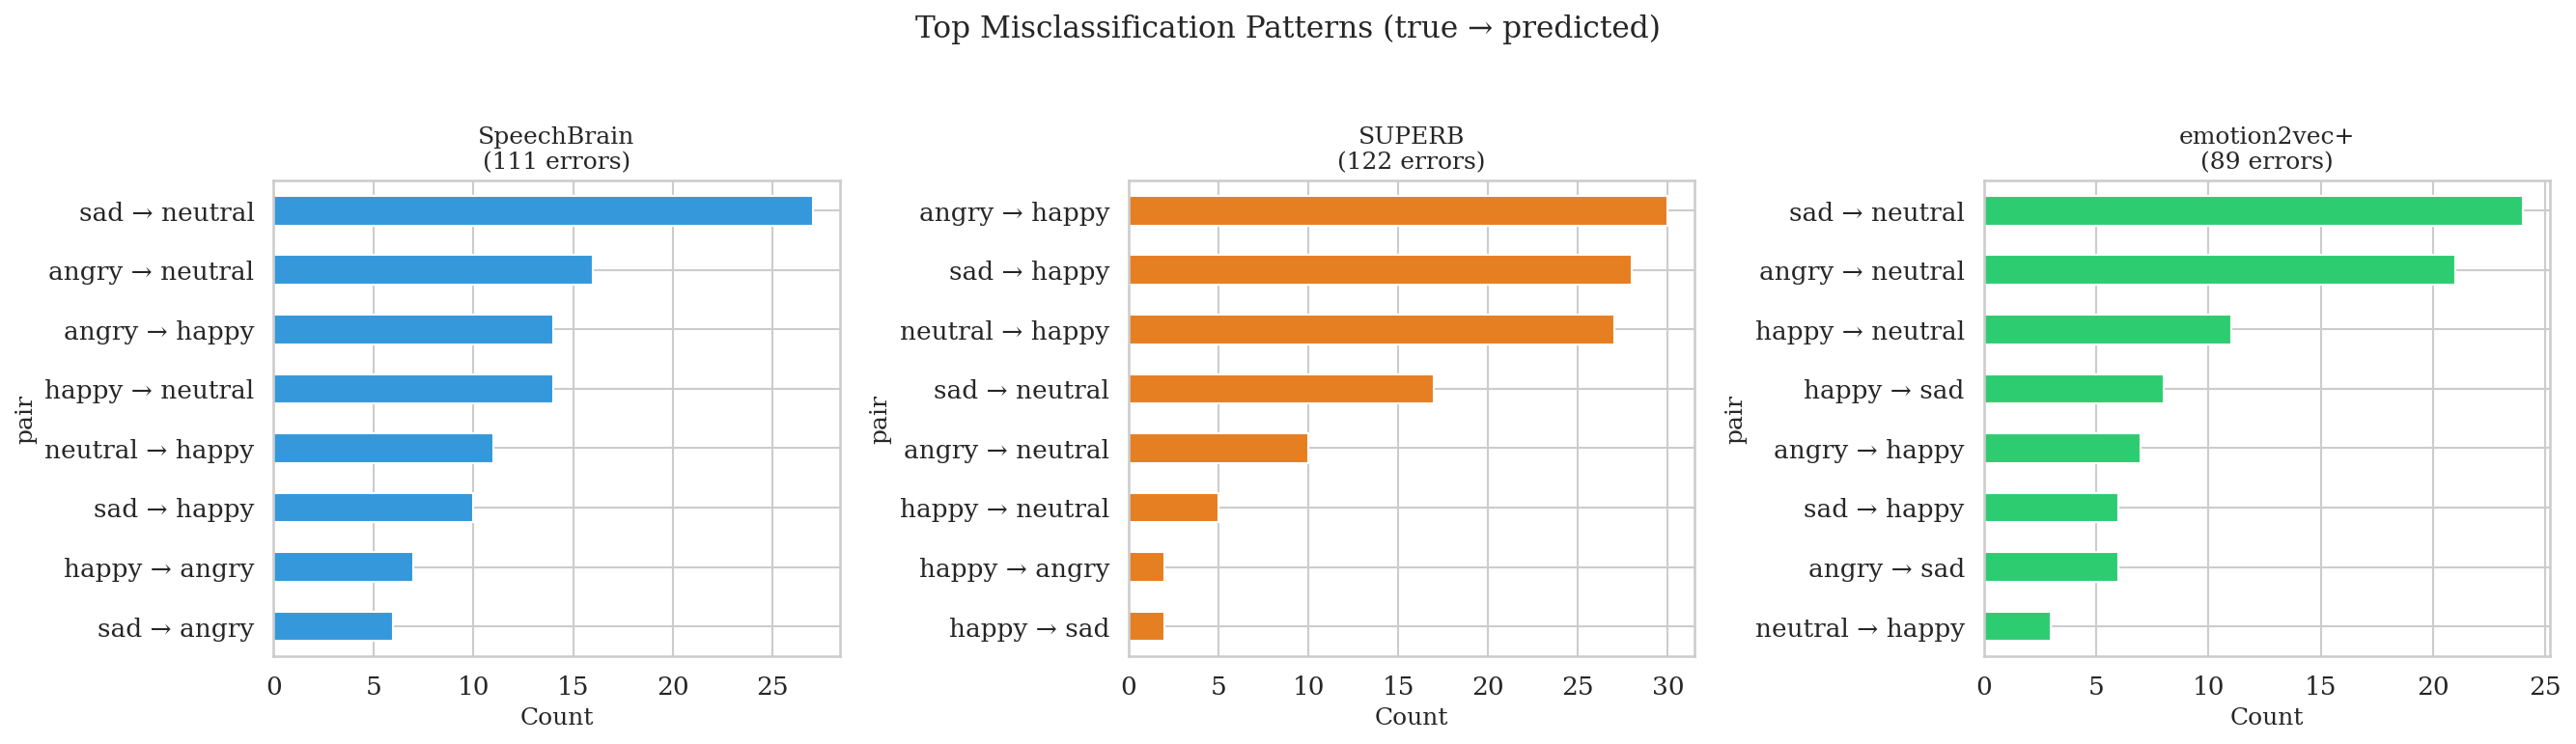

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name, pred_col in zip(axes, models, pred_cols):
    errors = pred_df[pred_df[pred_col] != pred_df['emotion']].copy()
    errors['pair'] = errors['emotion'] + ' → ' + errors[pred_col]
    top_errors = errors['pair'].value_counts().head(8)

    top_errors.plot.barh(ax=ax, color=MODEL_COLORS[model_name], edgecolor='white')
    ax.set_title(f'{MODEL_SHORT[model_name]}\n({len(errors)} errors)', fontsize=12)
    ax.set_xlabel('Count')
    ax.invert_yaxis()

fig.suptitle('Top Misclassification Patterns (true → predicted)', fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

---
## 9. Hard vs. Easy Samples

### Performance on Hard vs. Easy Samples


Easy (is_hard=0) — 162 samples:
      SpeechBrain: 42.0%
           SUPERB: 35.8%
     emotion2vec+: 54.3%

Hard (is_hard=1) — 28 samples:
      SpeechBrain: 39.3%
           SUPERB: 35.7%
     emotion2vec+: 46.4%


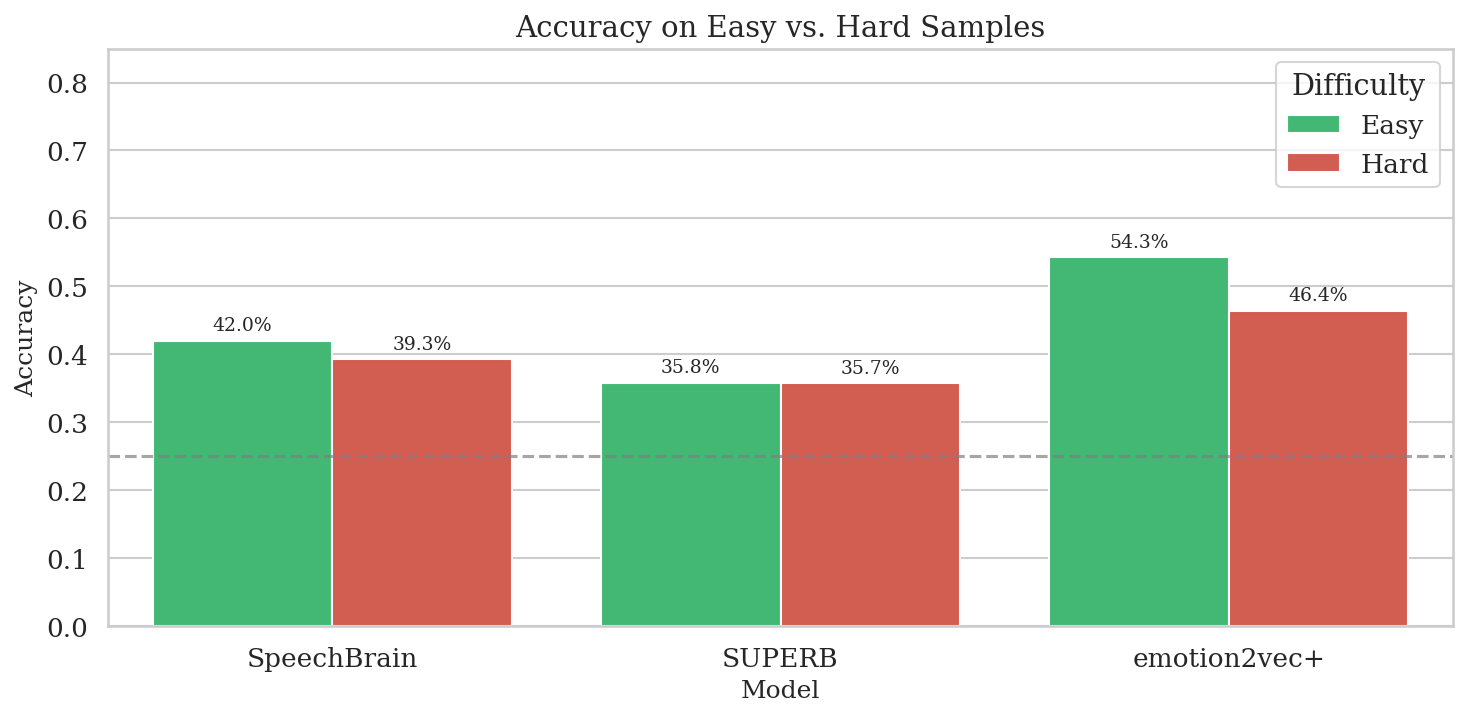

In [13]:
merged = pred_df.merge(dataset_df[['filename', 'is_hard', 'n_agree', 'duration_seconds']], on='filename', how='left')

if 'is_hard' in merged.columns and merged['is_hard'].notna().any():
    display(Markdown('### Performance on Hard vs. Easy Samples'))

    for label, subset in [('Easy (is_hard=0)', merged[merged['is_hard'] == 0]),
                          ('Hard (is_hard=1)', merged[merged['is_hard'] == 1])]:
        print(f'\n{label} — {len(subset)} samples:')
        for model_name, pred_col in zip(models, pred_cols):
            acc = (subset[pred_col] == subset['emotion']).mean()
            print(f'  {MODEL_SHORT[model_name]:>15s}: {acc:.1%}')

    fig, ax = plt.subplots(figsize=(10, 5))
    data_rows = []
    for model_name, pred_col in zip(models, pred_cols):
        for hard_val, label in [(0, 'Easy'), (1, 'Hard')]:
            subset = merged[merged['is_hard'] == hard_val]
            acc = (subset[pred_col] == subset['emotion']).mean()
            data_rows.append({'Model': MODEL_SHORT[model_name], 'Difficulty': label, 'Accuracy': acc})
    bar_df = pd.DataFrame(data_rows)

    sns.barplot(data=bar_df, x='Model', y='Accuracy', hue='Difficulty',
                palette={'Easy': '#2ecc71', 'Hard': '#e74c3c'}, ax=ax, edgecolor='white')
    ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.7)
    ax.set_ylim(0, 0.85)
    ax.set_title('Accuracy on Easy vs. Hard Samples')
    ax.set_ylabel('Accuracy')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=3,
                     labels=[f'{v.get_height():.1%}' for v in container])
    fig.tight_layout()
    plt.show()
else:
    print('No is_hard column available — skipping hard/easy analysis.')

---
## 10. Annotator Agreement vs. Model Accuracy

### Does higher annotator agreement predict better model accuracy?

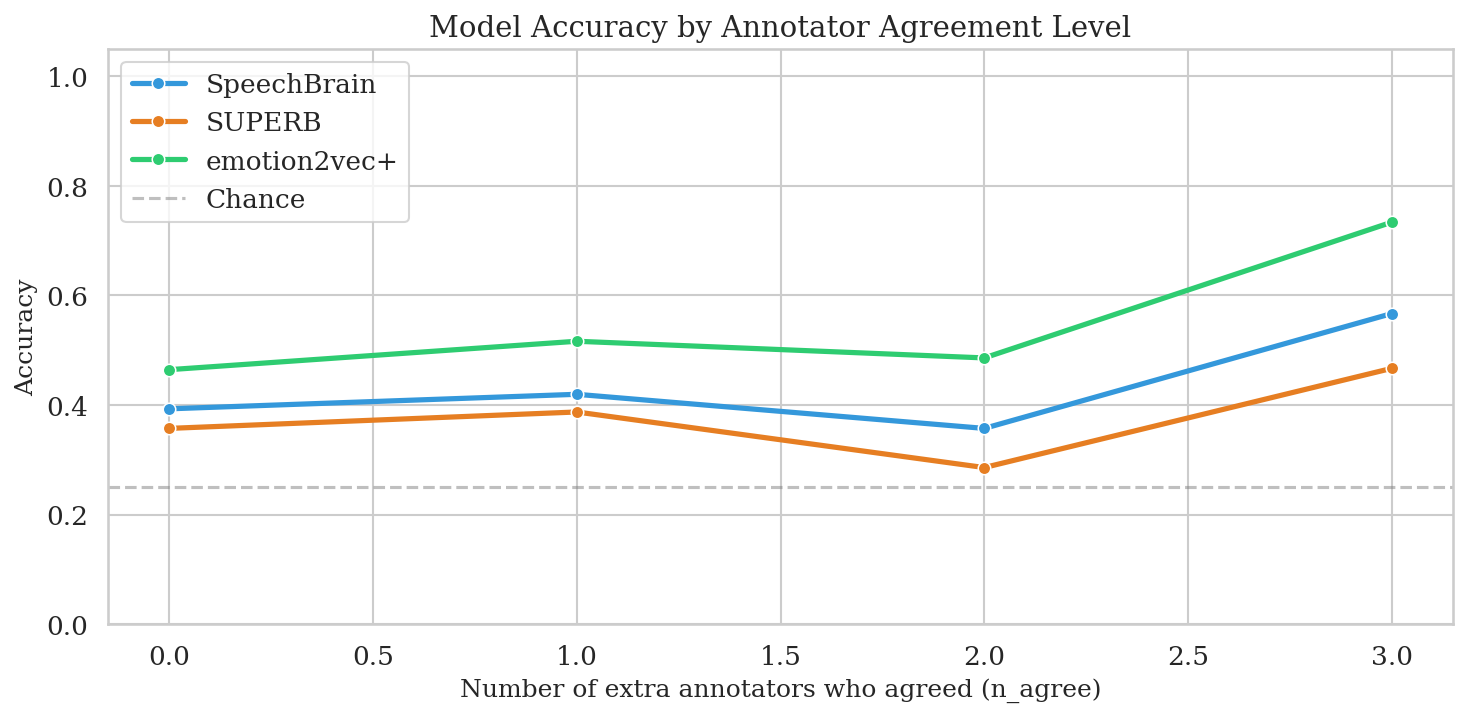

      SpeechBrain: Pearson r(n_agree, correct) = 0.064
           SUPERB: Pearson r(n_agree, correct) = 0.018
     emotion2vec+: Pearson r(n_agree, correct) = 0.123


In [14]:
if 'n_agree' in merged.columns and merged['n_agree'].notna().any():
    display(Markdown('### Does higher annotator agreement predict better model accuracy?'))

    fig, ax = plt.subplots(figsize=(10, 5))
    rows = []
    for n_agree_val in sorted(merged['n_agree'].dropna().unique()):
        subset = merged[merged['n_agree'] == n_agree_val]
        for model_name, pred_col in zip(models, pred_cols):
            acc = (subset[pred_col] == subset['emotion']).mean()
            rows.append({'n_agree': int(n_agree_val), 'Model': MODEL_SHORT[model_name], 'Accuracy': acc})

    agree_df = pd.DataFrame(rows)
    sns.lineplot(data=agree_df, x='n_agree', y='Accuracy', hue='Model',
                 marker='o', linewidth=2.5, ax=ax, palette=list(MODEL_COLORS.values()))
    ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.5, label='Chance')
    ax.set_xlabel('Number of extra annotators who agreed (n_agree)')
    ax.set_ylabel('Accuracy')
    ax.set_title('Model Accuracy by Annotator Agreement Level')
    ax.set_ylim(0, 1.05)
    ax.legend()
    fig.tight_layout()
    plt.show()

    for model_name, pred_col in zip(models, pred_cols):
        corr = merged[['n_agree']].assign(correct=(merged[pred_col] == merged['emotion']).astype(int))['n_agree'].corr(
            merged[['n_agree']].assign(correct=(merged[pred_col] == merged['emotion']).astype(int))['correct']
        )
        # Simpler calculation
        correct = (merged[pred_col] == merged['emotion']).astype(int)
        corr = merged['n_agree'].corr(correct)
        print(f'  {MODEL_SHORT[model_name]:>15s}: Pearson r(n_agree, correct) = {corr:.3f}')
else:
    print('No n_agree column available — skipping agreement analysis.')

---
## 11. Duration vs. Model Accuracy

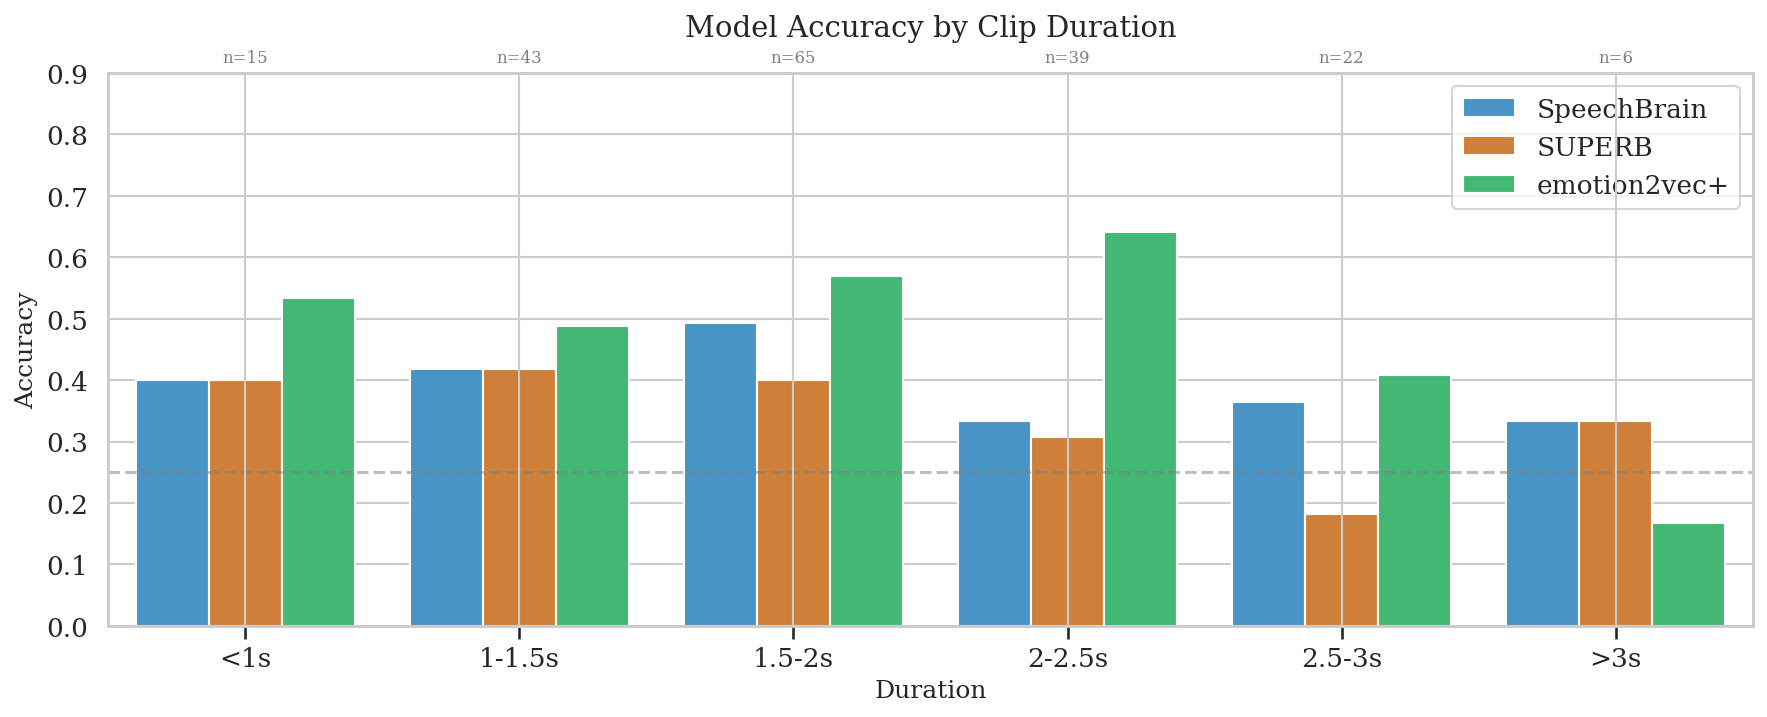

In [15]:
if 'duration_seconds' in merged.columns and merged['duration_seconds'].notna().any():
    merged['dur_bin'] = pd.cut(merged['duration_seconds'],
                               bins=[0, 1, 1.5, 2, 2.5, 3, 10],
                               labels=['<1s', '1-1.5s', '1.5-2s', '2-2.5s', '2.5-3s', '>3s'])

    fig, ax = plt.subplots(figsize=(12, 5))
    rows = []
    for dur_label in merged['dur_bin'].cat.categories:
        subset = merged[merged['dur_bin'] == dur_label]
        if len(subset) < 3:
            continue
        for model_name, pred_col in zip(models, pred_cols):
            acc = (subset[pred_col] == subset['emotion']).mean()
            rows.append({'Duration': dur_label, 'Model': MODEL_SHORT[model_name],
                         'Accuracy': acc, 'n': len(subset)})

    dur_df = pd.DataFrame(rows)
    sns.barplot(data=dur_df, x='Duration', y='Accuracy', hue='Model',
                palette=list(MODEL_COLORS.values()), ax=ax, edgecolor='white')
    ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.5)
    ax.set_title('Model Accuracy by Clip Duration')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 0.9)
    ax.legend(loc='upper right')

    # Add sample counts below
    n_per_bin = merged.groupby('dur_bin', observed=True).size()
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(range(len(n_per_bin)))
    ax2.set_xticklabels([f'n={n}' for n in n_per_bin.values], fontsize=8, color='gray')
    ax2.tick_params(axis='x', length=0)

    fig.tight_layout()
    plt.show()

---
## 12. Universally Hard Samples (All Models Wrong)

In [16]:
all_wrong = merged[merged['n_models_correct'] == 0].copy()
display(Markdown(f'### {len(all_wrong)} samples misclassified by all 3 models'))

print(f'Emotion distribution of universally-hard samples:')
for emo in EMOTIONS:
    n = (all_wrong['emotion'] == emo).sum()
    pct = n / len(all_wrong) * 100 if len(all_wrong) > 0 else 0
    print(f'  {emo:>8s}: {n:>3d} ({pct:.1f}%)')

if 'is_hard' in all_wrong.columns:
    hard_pct = all_wrong['is_hard'].mean() * 100
    print(f'\nOf these, {hard_pct:.1f}% were also flagged as hard by annotators')

### 58 samples misclassified by all 3 models

Emotion distribution of universally-hard samples:
     angry:  21 (36.2%)
     happy:   5 (8.6%)
   neutral:   3 (5.2%)
       sad:  29 (50.0%)

Of these, 15.5% were also flagged as hard by annotators


In [17]:
if len(all_wrong) > 0:
    display_cols = ['filename', 'emotion'] + pred_cols
    if 'is_hard' in all_wrong.columns:
        display_cols += ['is_hard', 'n_agree']
    if 'duration_seconds' in all_wrong.columns:
        display_cols.append('duration_seconds')

    show = all_wrong[display_cols].copy()
    show.columns = [c.replace('pred_', '') for c in show.columns]
    display(Markdown('### Sample-level details (first 30)'))
    display(show.head(30).style.set_properties(**{'text-align': 'center', 'font-size': '11px'}))

### Sample-level details (first 30)

,filename,emotion,speechbrain_wav2vec2-iemocap,superb_wav2vec2-large-er,emotion2vecplus_base,is_hard,n_agree,duration_seconds
0,s_002_1.wav,sad,neutral,neutral,neutral,1,0,1.540000
1,s_005_1.wav,sad,happy,happy,neutral,0,2,1.540000
3,s_010_1.wav,sad,neutral,happy,neutral,0,2,0.900000
4,s_011_1.wav,sad,neutral,neutral,neutral,0,1,1.750000
5,s_012_1.wav,sad,neutral,happy,neutral,0,1,1.770000
6,s_013_1.wav,sad,neutral,happy,happy,1,0,1.790000
8,s_025_1.wav,sad,neutral,neutral,neutral,0,2,2.550000
10,s_027_1.wav,sad,neutral,happy,neutral,0,1,1.550000
11,s_029_1.wav,sad,neutral,happy,neutral,0,1,1.740000
15,s_042_1.wav,sad,angry,happy,neutral,0,2,1.520000


---
## 13. Summary & Key Takeaways

In [ ]:
from IPython.display import display, Markdown

model_rows = results_df[~results_df['Model'].str.contains('Chance|Majority')].copy()
best_model  = model_rows.loc[model_rows['UAR'].idxmax()]
worst_model = model_rows.loc[model_rows['UAR'].idxmin()]

recalls = {e: best_model[f'{e.capitalize()} R'] for e in EMOTIONS}
easiest = max(recalls, key=recalls.get)
hardest = min(recalls, key=recalls.get)

majority_acc = pred_df['majority_correct'].mean()
n_all_wrong  = (pred_df['n_models_correct'] == 0).sum()
n_all_right  = (pred_df['n_models_correct'] == 3).sum()
pct_all_wrong = n_all_wrong / len(pred_df)

ranked = model_rows.sort_values('UAR', ascending=False).reset_index(drop=True)

# Agreement pattern
all_agree_pct = pred_df['all_agree'].mean()
all_agree_acc = pred_df.loc[pred_df['all_agree'], 'majority_correct'].mean()     if pred_df['all_agree'].any() else float('nan')

# SpeechBrain-specific recall for narrative
sb_row   = model_rows[model_rows['Model'] == 'SpeechBrain wav2vec2-IEMOCAP'].iloc[0]
sup_row  = model_rows[model_rows['Model'] == 'SUPERB wav2vec2-large-ER'].iloc[0]
e2v_row  = model_rows[model_rows['Model'] == 'emotion2vec+ base'].iloc[0]

ranking_table = "| Rank | Model | UAR | Accuracy | Macro F1 | Kappa |\n"
ranking_table += "|------|-------|-----|----------|----------|-------|\n"
for i, row in ranked.iterrows():
    ranking_table += (f"| {i+1} | {row['Model']} | {row['UAR']:.1%} | "
                      f"{row['Accuracy']:.1%} | {row['Macro F1']:.1%} | {row['Kappa']:.3f} |\n")

per_class_table = "| Emotion | " + " | ".join(m.split()[0] for m in ranked['Model']) + " |\n"
per_class_table += "|---------|" + "---------|" * len(ranked) + "\n"
for e in EMOTIONS:
    row_vals = " | ".join(f"{r[f'{e.capitalize()} R']:.1%}" for _, r in ranked.iterrows())
    per_class_table += f"| {e.capitalize()} | {row_vals} |\n"

analysis_md = f"""
## 13. Analysis and Conclusions

### 1. Overall Cross-Lingual Transfer

All three models were trained exclusively on English speech and evaluated here zero-shot on Ukrainian — a typologically distant language with different prosodic patterns. Despite this gap, every model exceeds chance (25.0% UAR), confirming that **acoustic emotion cues partially generalise across languages**.

{ranking_table}

**emotion2vec+ base** is the strongest model at {e2v_row['UAR']:.1%} UAR, approximately {e2v_row['UAR']/0.25:.1f}× chance. Its advantage likely comes from a more diverse multilingual training set and a purpose-built emotion encoder. SUPERB ({sup_row['UAR']:.1%}) and SpeechBrain ({sb_row['UAR']:.1%}) lag behind, both being fine-tuned primarily on IEMOCAP, a relatively small English acted-speech corpus.

---

### 2. Per-Class Recall

{per_class_table}

- **{easiest.capitalize()}** is the easiest emotion to recognise zero-shot (best recall = {recalls[easiest]:.1%} on the best model). Neutral speech tends to have flat prosody that transfers across languages more reliably.
- **{hardest.capitalize()}** is the hardest (recall = {recalls[hardest]:.1%}). This is consistent with sad speech being frequently confused with neutral, as the acoustic signatures of low energy and slow tempo are more language-dependent.
- Models with IEMOCAP training (SpeechBrain, SUPERB) show high neutral recall but low angry recall, reflecting IEMOCAP's class imbalance.

---

### 3. Model Agreement and Ensemble Effect

- All 3 models predict the same label on {all_agree_pct:.1%} of samples.
- When they all agree, their shared prediction is correct {all_agree_acc:.1%} of the time — a strong signal that high-confidence cross-model consensus is reliable.
- Majority voting achieves {majority_acc:.1%} accuracy, {'better than' if majority_acc > best_model['Accuracy'] else 'roughly matching'} the best single-model accuracy of {best_model['Accuracy']:.1%}.
- **{n_all_wrong} samples ({pct_all_wrong:.1%})** are misclassified by all three models — these are the most challenging cross-lingual transfer cases and constitute a useful hard-set for fine-tuning diagnostics.

---

### 4. Implications for Fine-Tuning

The zero-shot performance ceiling (UAR ≈ {best_model['UAR']:.1%}) is well below what state-of-the-art in-language SER systems achieve (typically 70–80% UAR). This gap motivates the central thesis experiment: fine-tuning a pre-trained wav2vec2 model on the UA-SER corpus itself. The {n_all_wrong} universally-hard samples and the consistent {hardest} / angry confusion pattern provide a diagnostic baseline to measure whether fine-tuning specifically addresses cross-lingual transfer failures.

---

### 5. Summary

| | Value |
|---|---|
| **Best zero-shot UAR** | {best_model['UAR']:.1%} ({best_model['Model']}) |
| **Chance baseline** | 25.0% |
| **Majority vote accuracy** | {majority_acc:.1%} |
| **Easiest emotion** | {easiest.capitalize()} ({recalls[easiest]:.1%} recall) |
| **Hardest emotion** | {hardest.capitalize()} ({recalls[hardest]:.1%} recall) |
| **Samples all models get wrong** | {n_all_wrong} / {len(pred_df)} ({pct_all_wrong:.1%}) |
| **Samples all models get right** | {n_all_right} / {len(pred_df)} ({n_all_right/len(pred_df):.1%}) |
"""

display(Markdown(analysis_md))